In [ ]:
FAST_MODE = False
SEED = 7

import subprocess, sys, os, time, json, math, warnings
warnings.filterwarnings("ignore")


def _pip(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])


try:
    import timesfm
except ImportError:
    print("Installing timesfm[torch] ... (~1-2 min)")
    _pip("timesfm[torch]")
    import timesfm

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

np.random.seed(SEED)
torch.manual_seed(SEED)

torch.set_float32_matmul_precision("high")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("=" * 78)
print(f"timesfm  : {getattr(timesfm, '__version__', 'n/a')}")
print(f"torch    : {torch.__version__}")
print(f"device   : {DEVICE}")
if DEVICE == "cuda":
    print(f"gpu      : {torch.cuda.get_device_name(0)} "
          f"({torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)")
print("=" * 78)

try:
    import jax
    from sklearn import preprocessing
    HAS_XREG_DEPS = True
except Exception as e:
    HAS_XREG_DEPS = False
    print(f"[warn] XReg deps missing ({e}); section 10 will be skipped.")

N_DAYS   = 1200
N_STORES = 6
REGIONS  = ["north", "north", "south", "south", "coast", "coast"]

dates = pd.date_range("2021-01-01", periods=N_DAYS, freq="D")
t     = np.arange(N_DAYS)
dow   = dates.dayofweek.values
doy   = dates.dayofyear.values

temp_base = 18 + 12 * np.sin(2 * np.pi * (doy - 105) / 365.25)
temp = temp_base + np.cumsum(np.random.normal(0, 0.6, N_DAYS)) * 0.15
temp = temp - np.linspace(0, temp[-1] - temp_base[-1], N_DAYS)

holiday_doy = {1, 2, 45, 100, 120, 185, 240, 300, 358, 359, 360, 361, 362, 363, 364, 365}
is_holiday = np.isin(doy, list(holiday_doy)).astype(int)

rows = []
for s in range(N_STORES):
    level      = 180 + 60 * s
    slope      = np.random.uniform(0.02, 0.09)
    week_amp   = np.random.uniform(15, 35)
    year_amp   = np.random.uniform(20, 45)
    elasticity = np.random.uniform(18, 32)
    promo_lift = np.random.uniform(35, 70)
    temp_beta  = np.random.uniform(0.8, 2.2)
    phase      = np.random.uniform(0, 2 * np.pi)

    base_price = np.random.uniform(9.0, 13.0)
    price = base_price + np.random.normal(0, 0.25, N_DAYS)
    promo = (np.random.rand(N_DAYS) < 0.09).astype(int)
    price = price - promo * np.random.uniform(1.2, 2.2)

    weekly = week_amp * np.array([0.9, 0.7, 0.7, 0.85, 1.25, 1.8, 1.5])[dow]
    yearly = year_amp * np.sin(2 * np.pi * doy / 365.25 + phase)

    sales = (level
             + slope * t
             + weekly
             + yearly
             - elasticity * (price - base_price)
             + promo_lift * promo
             + 55 * is_holiday
             + temp_beta * (temp - 18)
             + np.random.normal(0, 14, N_DAYS))
    sales = np.clip(sales, 5, None)

    rows.append(pd.DataFrame({
        "date": dates,
        "store": f"store_{s}",
        "region": REGIONS[s],
        "sales": sales.astype(np.float32),
        "price": price.astype(np.float32),
        "promo": promo.astype(np.int32),
        "holiday": is_holiday.astype(np.int32),
        "dow": dow.astype(np.int32),
        "temp": temp.astype(np.float32),
    }))

df = pd.concat(rows, ignore_index=True)
STORES = sorted(df["store"].unique())
print(f"\nDataset: {df.shape[0]:,} rows | {len(STORES)} stores | "
      f"{dates[0].date()} → {dates[-1].date()}")
print(df.head(3).to_string(index=False))

wide = df.pivot(index="date", columns="store", values="sales")

SEASON = 7
HORIZON = 56

print("\nLoading google/timesfm-2.5-200m-pytorch ...")
t0 = time.time()
model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)
print(f"loaded in {time.time() - t0:.1f}s")

BASE_CFG = dict(
    max_context=1024,
    max_horizon=256,
    normalize_inputs=True,
    per_core_batch_size=16,
    use_continuous_quantile_head=True,
    force_flip_invariance=True,
    infer_is_positive=True,
    fix_quantile_crossing=True,
    return_backcast=False,
)
model.compile(timesfm.ForecastConfig(**BASE_CFG))
print("compiled:", {k: v for k, v in BASE_CFG.items() if k in
                    ("max_context", "max_horizon", "per_core_batch_size")})


def recompile(**overrides):
    cfg = {**BASE_CFG, **overrides}
    model.compile(timesfm.ForecastConfig(**cfg))
    return cfg

In [ ]:
IDX_MEAN, IDX_Q10, IDX_Q50, IDX_Q90 = 0, 1, 5, 9
QUANTILES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

target_store = STORES[0]
series = wide[target_store].values.astype(np.float32)
train, actual = series[:-HORIZON], series[-HORIZON:]

point, quant = model.forecast(horizon=HORIZON, inputs=[train.copy()])
print(f"\npoint    {point.shape}   # (n_series, horizon)")
print(f"quantile {quant.shape}   # (n_series, horizon, 10)")

fig, ax = plt.subplots(figsize=(14, 5))
hist_n = 180
ax.plot(dates[-HORIZON - hist_n:-HORIZON], train[-hist_n:], color="#334155",
        lw=1.2, label="history")
ax.plot(dates[-HORIZON:], actual, color="#0f172a", lw=1.6, label="actual")
ax.plot(dates[-HORIZON:], point[0], color="#ea580c", lw=2, label="TimesFM median")
for lo, hi, a in [(1, 9, .12), (2, 8, .16), (3, 7, .20), (4, 6, .24)]:
    ax.fill_between(dates[-HORIZON:], quant[0, :, lo], quant[0, :, hi],
                    color="#ea580c", alpha=a, lw=0)
ax.axvline(dates[-HORIZON], color="#94a3b8", ls="--", lw=1)
ax.set_title(f"TimesFM 2.5 zero-shot — {target_store}, {HORIZON}-day horizon "
             f"(fan = q10…q90)")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.show()

print("\n--- output anatomy ---")
print("index 0 = MEAN (not q0!). indices 1..9 = q10..q90. index 5 = median.")
print("point_forecast is literally quantile[..., 5]:",
      np.allclose(point, quant[..., IDX_Q50]))
print("monotone quantiles (fix_quantile_crossing):",
      bool(np.all(np.diff(quant[0, :, 1:], axis=-1) >= -1e-4)))
row = pd.DataFrame({
    "index": range(10),
    "meaning": ["mean"] + [f"q{int(q*100)}" for q in QUANTILES],
    "day+1": quant[0, 0].round(1),
    f"day+{HORIZON}": quant[0, -1].round(1),
})
print(row.to_string(index=False))
print("Interval width grows with horizon — day+1 q10..q90 span "
      f"{quant[0,0,9]-quant[0,0,1]:.1f}, day+{HORIZON} span "
      f"{quant[0,-1,9]-quant[0,-1,1]:.1f}")


def seasonal_naive(history, horizon, season=SEASON):
    """Repeat the last full season forward — the baseline you must beat."""
    reps = int(np.ceil(horizon / season))
    return np.tile(history[-season:], reps)[:horizon]


def pinball(actual, q, quantiles=QUANTILES):
    """Mean pinball (quantile) loss over q10..q90 — the probabilistic metric."""
    out = []
    for i, tau in enumerate(quantiles, start=1):
        e = actual - q[:, i]
        out.append(np.mean(np.maximum(tau * e, (tau - 1) * e)))
    return float(np.mean(out))


def evaluate(actual, pred, history, q=None, season=SEASON):
    actual, pred = np.asarray(actual, float), np.asarray(pred, float)
    err = actual - pred

    scale = np.mean(np.abs(history[season:] - history[:-season])) + 1e-9
    m = {
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "MAPE%": float(
            np.mean(np.abs(err / np.maximum(np.abs(actual), 1e-9))) * 100
        ),
        "sMAPE%": float(
            np.mean(
                2 * np.abs(err) /
                (np.abs(actual) + np.abs(pred) + 1e-9)
            ) * 100
        ),
        "MASE": float(np.mean(np.abs(err)) / scale),
    }
    if q is not None:
        m["pinball"] = pinball(actual, q)
        m["cov80%"] = float(
            np.mean(
                (actual >= q[:, IDX_Q10]) &
                (actual <= q[:, IDX_Q90])
            ) * 100
        )
    return m


base_pred = seasonal_naive(train, HORIZON)
cmp = pd.DataFrame({
    "TimesFM 2.5": evaluate(actual, point[0], train, quant[0]),
    "seasonal naive": evaluate(actual, base_pred, train),
    "last value": evaluate(
        actual,
        np.repeat(train[-1], HORIZON),
        train
    ),
}).T
print("\n--- single-series accuracy ---")
print(cmp.round(3).to_string())
print("MASE < 1 means you beat seasonal naive. cov80% should sit near 80.")

inputs = [
    wide[s].values[:-HORIZON].astype(np.float32).copy()
    for s in STORES
]
t0 = time.time()
b_point, b_quant = model.forecast(
    horizon=HORIZON,
    inputs=list(inputs)
)
elapsed = time.time() - t0
print(f"\n{len(STORES)} series forecast in {elapsed:.2f}s "
      f"({elapsed/len(STORES)*1000:.0f} ms/series)")

per_series = {}
for i, s in enumerate(STORES):
    hist = wide[s].values[:-HORIZON]
    act = wide[s].values[-HORIZON:]
    per_series[s] = evaluate(
        act,
        b_point[i],
        hist,
        b_quant[i]
    )

tbl = pd.DataFrame(per_series).T
print(tbl.round(3).to_string())
print("mean MASE:", round(tbl["MASE"].mean(), 3),
      "| mean 80% coverage:", round(tbl["cov80%"].mean(), 1))

fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=True)
for ax, s, i in zip(
    axes.ravel(),
    STORES,
    range(len(STORES))
):
    hist = wide[s].values[:-HORIZON]
    ax.plot(
        dates[-HORIZON-90:-HORIZON],
        hist[-90:],
        color="#475569",
        lw=1
    )
    ax.plot(
        dates[-HORIZON:],
        wide[s].values[-HORIZON:],
        color="#0f172a",
        lw=1.4
    )
    ax.plot(
        dates[-HORIZON:],
        b_point[i],
        color="#ea580c",
        lw=1.8
    )
    ax.fill_between(
        dates[-HORIZON:],
        b_quant[i, :, IDX_Q10],
        b_quant[i, :, IDX_Q90],
        color="#ea580c",
        alpha=.18,
        lw=0
    )
    ax.set_title(
        f"{s}  MASE={per_series[s]['MASE']:.2f}",
        fontsize=10
    )
    ax.tick_params(labelsize=8)

fig.suptitle(
    "Batched zero-shot forecasts "
    "(orange = median, band = 80% PI)"
)
plt.tight_layout()
plt.show()

In [ ]:
N_FOLDS = 3 if FAST_MODE else 6
STEP = HORIZON
print(f"\n--- rolling-origin backtest: {N_FOLDS} folds x {HORIZON}d x "
      f"{len(STORES)} series ---")

fold_rows = []
for k in range(N_FOLDS):
    end = N_DAYS - k * STEP
    cut = end - HORIZON
    fold_inputs, fold_actuals, fold_hists = [], [], []

    for s in STORES:
        v = wide[s].values.astype(np.float32)
        fold_inputs.append(v[:cut].copy())
        fold_actuals.append(v[cut:end])
        fold_hists.append(v[:cut])

    fp, fq = model.forecast(
        horizon=HORIZON,
        inputs=list(fold_inputs)
    )

    for i, s in enumerate(STORES):
        m_tfm = evaluate(
            fold_actuals[i],
            fp[i],
            fold_hists[i],
            fq[i]
        )
        m_snv = evaluate(
            fold_actuals[i],
            seasonal_naive(fold_hists[i], HORIZON),
            fold_hists[i]
        )
        fold_rows.append({
            "fold": k,
            "store": s,
            "model": "TimesFM",
            **m_tfm
        })
        fold_rows.append({
            "fold": k,
            "store": s,
            "model": "snaive",
            **m_snv
        })

bt = pd.DataFrame(fold_rows)
summary = bt.groupby("model")[
    ["MAE", "RMSE", "sMAPE%", "MASE"]
].mean()
print(summary.round(3).to_string())

lift = (
    1 -
    summary.loc["TimesFM", "MASE"] /
    summary.loc["snaive", "MASE"]
)
print(
    f"TimesFM reduces MASE by "
    f"{lift*100:.1f}% vs seasonal naive, zero-shot."
)

fig, ax = plt.subplots(figsize=(10, 4))
piv = bt.pivot_table(
    index="fold",
    columns="model",
    values="MASE"
)
piv.plot(
    kind="bar",
    ax=ax,
    color=["#ea580c", "#94a3b8"],
    width=.8
)
ax.set_ylabel("MASE (lower is better)")
ax.axhline(1.0, color="k", ls=":", lw=1)
ax.set_title("Rolling-origin backtest — MASE per fold")
plt.tight_layout()
plt.show()

ctx_grid = (
    [128, 512]
    if FAST_MODE
    else [64, 128, 256, 512, 1024]
)
print(f"\n--- context ablation {ctx_grid} ---")

abl = []
for ctx in ctx_grid:
    recompile(max_context=ctx)

    ins = [
        wide[s].values[:-HORIZON][-ctx:]
        .astype(np.float32)
        .copy()
        for s in STORES
    ]

    t0 = time.time()
    p, q = model.forecast(
        horizon=HORIZON,
        inputs=list(ins)
    )
    dt = time.time() - t0

    ms = [
        evaluate(
            wide[s].values[-HORIZON:],
            p[i],
            wide[s].values[:-HORIZON],
            q[i]
        )
        for i, s in enumerate(STORES)
    ]

    abl.append({
        "context": ctx,
        "MASE": np.mean([m["MASE"] for m in ms]),
        "sMAPE%": np.mean([m["sMAPE%"] for m in ms]),
        "cov80%": np.mean([m["cov80%"] for m in ms]),
        "sec": round(dt, 2)
    })

abl = pd.DataFrame(abl)
print(abl.round(3).to_string(index=False))

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(
    abl["context"],
    abl["MASE"],
    "o-",
    color="#ea580c"
)
ax1.set_xscale("log", base=2)
ax1.set_xlabel("context length (days)")
ax1.set_ylabel("MASE", color="#ea580c")

ax2 = ax1.twinx()
ax2.bar(
    abl["context"],
    abl["sec"],
    width=abl["context"] * 0.35,
    alpha=.25,
    color="#0369a1"
)
ax2.set_ylabel("wall-clock (s)", color="#0369a1")
ax1.set_title("Accuracy vs. context length vs. cost")
plt.tight_layout()
plt.show()

recompile()

In [ ]:
if HAS_XREG_DEPS:
    CTX_X, H_X = 512, 56
    recompile(
        max_context=CTX_X,
        max_horizon=128,
        return_backcast=True
    )

    x_inputs = []
    dyn_num = {"price": [], "temp": []}
    dyn_cat = {"promo": [], "holiday": [], "dow": []}
    stat_cat = {"region": [], "store": []}

    for s in STORES:
        g = df[df["store"] == s].reset_index(drop=True)
        n = len(g)
        ctx_lo, ctx_hi = n - H_X - CTX_X, n - H_X

        x_inputs.append(
            g["sales"]
            .values[ctx_lo:ctx_hi]
            .astype(np.float32)
        )

        for name, col in [
            ("price", "price"),
            ("temp", "temp")
        ]:
            dyn_num[name].append(
                g[col]
                .values[ctx_lo:n]
                .astype(np.float32)
            )

        for name, col in [
            ("promo", "promo"),
            ("holiday", "holiday"),
            ("dow", "dow")
        ]:
            dyn_cat[name].append(
                g[col]
                .values[ctx_lo:n]
                .astype(np.int32)
                .tolist()
            )

        stat_cat["region"].append(g["region"].iloc[0])
        stat_cat["store"].append(s)

    x_actuals = [
        wide[s].values[-H_X:]
        for s in STORES
    ]
    x_hists = [
        wide[s].values[:-H_X]
        for s in STORES
    ]

    print(
        f"\n--- XReg: inputs len={len(x_inputs[0])}, "
        f"covariate len={len(dyn_num['price'][0])} "
        f"=> inferred horizon "
        f"{len(dyn_num['price'][0]) - len(x_inputs[0])} ---"
    )

    xreg_results = {}

    for mode in ["xreg + timesfm", "timesfm + xreg"]:
        t0 = time.time()

        p_list, q_list = model.forecast_with_covariates(
            inputs=[a.copy() for a in x_inputs],
            dynamic_numerical_covariates=dyn_num,
            dynamic_categorical_covariates=dyn_cat,
            static_categorical_covariates=stat_cat,
            xreg_mode=mode,
            normalize_xreg_target_per_input=True,
            ridge=1.0,
            force_on_cpu=False,
        )

        dt = time.time() - t0

        ms = [
            evaluate(
                x_actuals[i],
                np.asarray(p_list[i]),
                x_hists[i],
                np.asarray(q_list[i])
            )
            for i in range(len(STORES))
        ]

        xreg_results[mode] = (
            np.asarray(p_list),
            np.asarray(q_list),
            ms,
            dt
        )

        print(
            f"{mode:>16}: "
            f"MASE={np.mean([m['MASE'] for m in ms]):.3f} "
            f"sMAPE={np.mean([m['sMAPE%'] for m in ms]):.2f}% "
            f"({dt:.1f}s)"
        )

    recompile(
        max_context=CTX_X,
        max_horizon=128,
        return_backcast=False
    )

    p_uni, q_uni = model.forecast(
        horizon=H_X,
        inputs=[a.copy() for a in x_inputs]
    )

    ms_uni = [
        evaluate(
            x_actuals[i],
            p_uni[i],
            x_hists[i],
            q_uni[i]
        )
        for i in range(len(STORES))
    ]

    print(
        f"{'univariate':>16}: "
        f"MASE={np.mean([m['MASE'] for m in ms_uni]):.3f} "
        f"sMAPE={np.mean([m['sMAPE%'] for m in ms_uni]):.2f}%"
    )

    comp = pd.DataFrame({
        "univariate": pd.DataFrame(ms_uni).mean(),
        "xreg + timesfm": pd.DataFrame(
            xreg_results["xreg + timesfm"][2]
        ).mean(),
        "timesfm + xreg": pd.DataFrame(
            xreg_results["timesfm + xreg"][2]
        ).mean(),
    }).T

    print("\n", comp.round(3).to_string())

    best_mode = min(
        xreg_results,
        key=lambda m: np.mean(
            [x["MASE"] for x in xreg_results[m][2]]
        )
    )
    p_best = xreg_results[best_mode][0]

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(15, 7),
        sharex=True
    )

    for ax, i in zip(axes.ravel(), range(4)):
        ax.plot(
            dates[-H_X - 60:-H_X],
            x_hists[i][-60:],
            color="#475569",
            lw=1
        )
        ax.plot(
            dates[-H_X:],
            x_actuals[i],
            color="#0f172a",
            lw=1.5,
            label="actual"
        )
        ax.plot(
            dates[-H_X:],
            p_uni[i],
            color="#94a3b8",
            lw=1.6,
            ls="--",
            label="univariate"
        )
        ax.plot(
            dates[-H_X:],
            p_best[i],
            color="#ea580c",
            lw=1.8,
            label=f"{best_mode}"
        )

        pr = df[
            df["store"] == STORES[i]
        ]["promo"].values[-H_X:]

        for j in np.where(pr == 1)[0]:
            d = dates[-H_X + j]
            ax.axvspan(
                d - pd.Timedelta(hours=12),
                d + pd.Timedelta(hours=12),
                color="#16a34a",
                alpha=.25,
                lw=0
            )

        ax.set_title(STORES[i], fontsize=10)
        ax.tick_params(labelsize=8)

    axes[0, 0].legend(fontsize=8)
    fig.suptitle(
        "Covariate forecasting "
        "(green = promotion days known in advance)"
    )
    plt.tight_layout()
    plt.show()
else:
    print(
        "\n[skip] section 10 — "
        "install scikit-learn + jax to run XReg."
    )

recompile()

In [ ]:
sig = wide[STORES[1]].values.astype(np.float32).copy()
truth_idx = [
    N_DAYS - 210,
    N_DAYS - 128,
    N_DAYS - 61,
    N_DAYS - 20
]

sig[truth_idx[0]] *= 1.9
sig[truth_idx[1]] *= 0.35
sig[truth_idx[2]:truth_idx[2] + 5] *= 1.5
sig[truth_idx[3]] *= 0.45

DET_WIN, DET_START = 14, N_DAYS - 280
flags = []

for start in range(
    DET_START,
    N_DAYS - DET_WIN + 1,
    DET_WIN
):
    ctx = sig[max(0, start - 512):start]

    p, q = model.forecast(
        horizon=DET_WIN,
        inputs=[ctx.copy()]
    )

    act = sig[start:start + DET_WIN]
    lo90 = q[0, :, IDX_Q10]
    hi90 = q[0, :, IDX_Q90]

    lo_ext = (
        q[0, :, IDX_Q10] -
        1.5 * (
            q[0, :, IDX_Q50] -
            q[0, :, IDX_Q10]
        )
    )
    hi_ext = (
        q[0, :, IDX_Q90] +
        1.5 * (
            q[0, :, IDX_Q90] -
            q[0, :, IDX_Q50]
        )
    )

    for j in range(DET_WIN):
        sev = (
            "CRITICAL"
            if (
                act[j] < lo_ext[j] or
                act[j] > hi_ext[j]
            )
            else "WARNING"
            if (
                act[j] < lo90[j] or
                act[j] > hi90[j]
            )
            else "ok"
        )

        flags.append({
            "i": start + j,
            "date": dates[start + j],
            "actual": act[j],
            "lo": lo90[j],
            "hi": hi90[j],
            "sev": sev,
            "z": (
                act[j] -
                q[0, j, IDX_Q50]
            ) / max(
                (hi90[j] - lo90[j]) / 2.563,
                1e-6
            )
        })

fl = pd.DataFrame(flags)
alerts = fl[fl.sev != "ok"]

print(
    f"\n--- anomaly detection: "
    f"{len(alerts)} flags in {len(fl)} points "
    f"({len(alerts)/len(fl)*100:.1f}% — "
    f"expect ~20% by construction) ---"
)

print(
    alerts[
        alerts.sev == "CRITICAL"
    ][
        ["date", "actual", "lo", "hi", "z", "sev"]
    ]
    .round(2)
    .to_string(index=False)
)

print(
    "injected anomalies at:",
    [str(dates[i].date()) for i in truth_idx]
)

fig, ax = plt.subplots(figsize=(14, 4.5))

ax.plot(
    fl["date"],
    fl["actual"],
    color="#0f172a",
    lw=1.1,
    label="observed"
)

ax.fill_between(
    fl["date"],
    fl["lo"],
    fl["hi"],
    color="#0369a1",
    alpha=.15,
    lw=0,
    label="80% predictive interval"
)

w = fl[fl.sev == "WARNING"]
c = fl[fl.sev == "CRITICAL"]

ax.scatter(
    w["date"],
    w["actual"],
    s=28,
    color="#f59e0b",
    zorder=3,
    label="warning"
)

ax.scatter(
    c["date"],
    c["actual"],
    s=60,
    color="#dc2626",
    zorder=4,
    marker="X",
    label="critical"
)

ax.set_title(
    "Anomaly detection from TimesFM predictive intervals"
)
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

LONG_H = 256
long_train = (
    wide[STORES[2]]
    .values[:-LONG_H]
    .astype(np.float32)
)
long_act = wide[STORES[2]].values[-LONG_H:]

recompile(max_horizon=256)

p_direct, q_direct = model.forecast(
    horizon=LONG_H,
    inputs=[long_train.copy()]
)

recompile(max_horizon=128)

CHUNK = 64
ctx_roll = long_train.copy()
rec = []

for _ in range(LONG_H // CHUNK):
    p_c, _ = model.forecast(
        horizon=CHUNK,
        inputs=[ctx_roll[-1024:].copy()]
    )
    rec.append(p_c[0])
    ctx_roll = np.concatenate([
        ctx_roll,
        p_c[0]
    ])

p_rec = np.concatenate(rec)

print(f"\n--- long horizon ({LONG_H} days) ---")

print(
    pd.DataFrame({
        "direct": evaluate(
            long_act,
            p_direct[0],
            long_train,
            q_direct[0]
        ),
        f"recursive x{CHUNK}": evaluate(
            long_act,
            p_rec,
            long_train
        ),
    })
    .T
    .round(3)
    .to_string()
)

fig, ax = plt.subplots(figsize=(14, 4.5))

ax.plot(
    dates[-LONG_H-120:-LONG_H],
    long_train[-120:],
    color="#475569",
    lw=1
)

ax.plot(
    dates[-LONG_H:],
    long_act,
    color="#0f172a",
    lw=1.4,
    label="actual"
)

ax.plot(
    dates[-LONG_H:],
    p_direct[0],
    color="#ea580c",
    lw=1.8,
    label="direct"
)

ax.plot(
    dates[-LONG_H:],
    p_rec,
    color="#7c3aed",
    lw=1.5,
    ls="--",
    label=f"recursive ({CHUNK}-day chunks)"
)

ax.fill_between(
    dates[-LONG_H:],
    q_direct[0, :, IDX_Q10],
    q_direct[0, :, IDX_Q90],
    color="#ea580c",
    alpha=.15,
    lw=0
)

ax.legend()
ax.set_title(
    "Direct vs recursive long-horizon forecasting"
)
plt.tight_layout()
plt.show()

recompile()

Installing timesfm[torch] ... (~1-2 min)
timesfm  : n/a
torch    : 2.11.0+cpu
device   : cpu

Dataset: 7,200 rows | 6 stores | 2021-01-01 → 2024-04-14
      date   store region      sales     price  promo  holiday  dow     temp
2021-01-01 store_0  north 252.309631 11.046662      0        1    4 6.293066
2021-01-02 store_0  north 331.059021  9.182004      1        1    5 6.539666
2021-01-03 store_0  north 204.982773 10.786095      0        0    6 6.487534

Loading google/timesfm-2.5-200m-pytorch ...


config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  925MB            

model.safetensors: downloading bytes:           |  0.00B            

loaded in 12.6s
compiled: {'max_context': 1024, 'max_horizon': 256, 'per_core_batch_size': 16}

point    (1, 56)   # (n_series, horizon)
quantile (1, 56, 10)   # (n_series, horizon, 10)


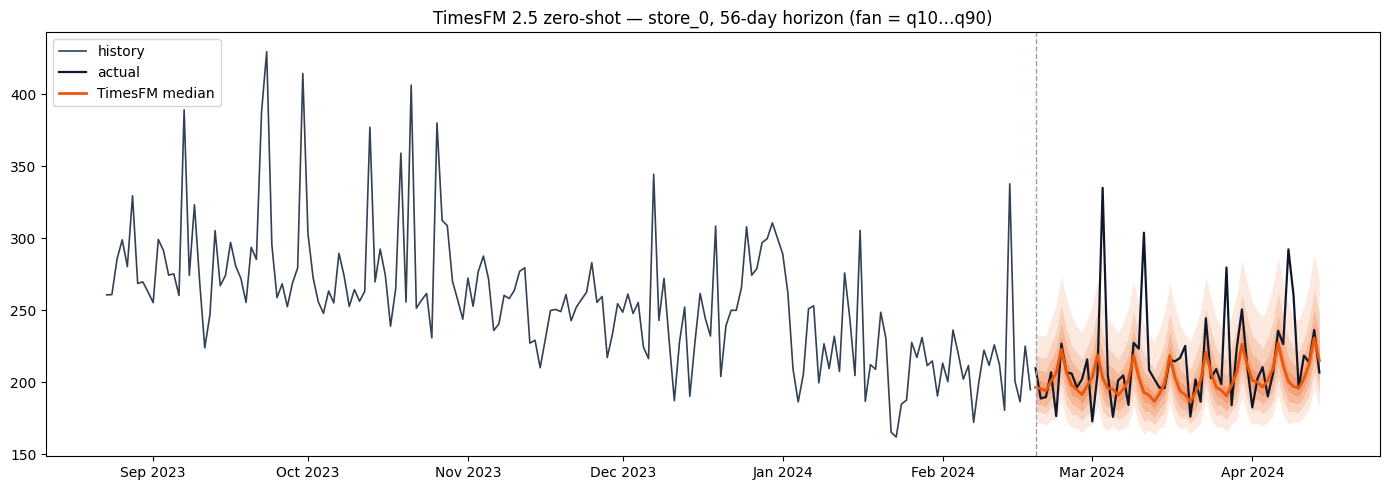


--- output anatomy ---
index 0 = MEAN (not q0!). indices 1..9 = q10..q90. index 5 = median.
point_forecast is literally quantile[..., 5]: True
monotone quantiles (fix_quantile_crossing): True
 index meaning      day+1     day+56
     0    mean 202.399994 223.199997
     1     q10 171.199997 182.399994
     2     q20 179.600006 192.100006
     3     q30 185.699997 200.100006
     4     q40 191.300003 207.500000
     5     q50 196.600006 215.300003
     6     q60 202.300003 223.699997
     7     q70 209.399994 234.000000
     8     q80 218.800003 247.699997
     9     q90 233.899994 271.299988
Interval width grows with horizon — day+1 q10..q90 span 62.8, day+56 span 88.9

--- single-series accuracy ---
                   MAE    RMSE   MAPE%  sMAPE%   MASE  pinball  cov80%
TimesFM 2.5     19.258  32.813   8.080   8.690  0.608    8.325  91.071
seasonal naive  36.704  59.394  16.955  15.151  1.158      NaN     NaN
last value      24.076  36.438  10.085  11.009  0.760      NaN     NaN
MASE 

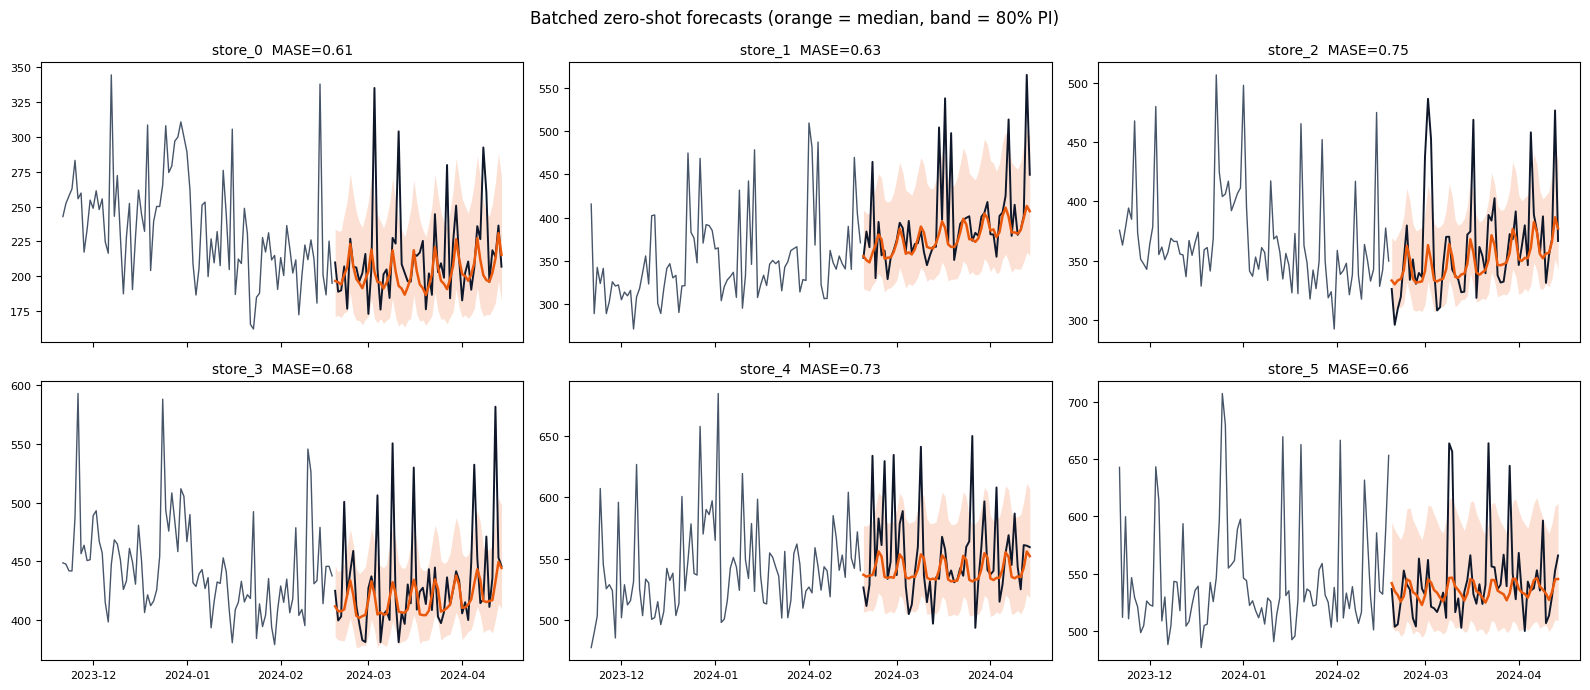


--- rolling-origin backtest: 6 folds x 56d x 6 series ---
            MAE    RMSE  sMAPE%   MASE
model                                 
TimesFM  23.583  38.279   5.818  0.718
snaive   41.863  57.739  10.265  1.277
TimesFM reduces MASE by 43.8% vs seasonal naive, zero-shot.


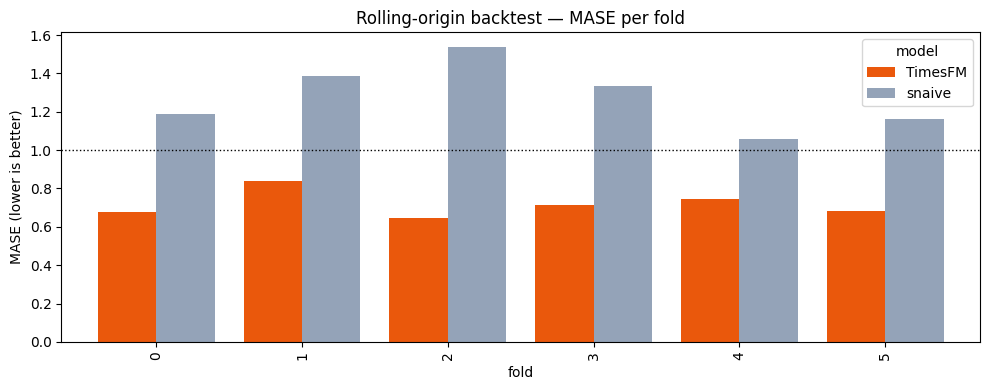


--- context ablation [64, 128, 256, 512, 1024] ---
 context  MASE  sMAPE%  cov80%  sec
      64 0.840   7.119  86.607 1.87
     128 0.823   6.969  87.500 2.22
     256 0.793   6.499  86.310 4.24
     512 0.693   5.806  88.095 4.78
    1024 0.677   5.655  86.905 8.11


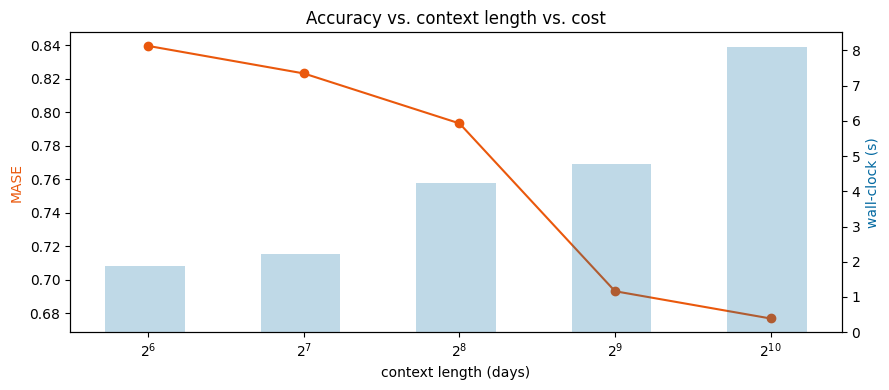


--- XReg: inputs len=512, covariate len=568 => inferred horizon 56 ---
  xreg + timesfm: MASE=0.412 sMAPE=3.69%  (4.6s)
  timesfm + xreg: MASE=0.410 sMAPE=3.81%  (3.6s)
      univariate: MASE=0.693 sMAPE=5.81%

                    MAE    RMSE  MAPE%  sMAPE%   MASE  pinball   cov80%
univariate      23.062  38.404  5.487   5.806  0.693   10.051   88.095
xreg + timesfm  13.689  16.678  3.656   3.686  0.412    5.215   77.976
timesfm + xreg  13.561  16.321  3.731   3.807  0.410    5.970  100.000


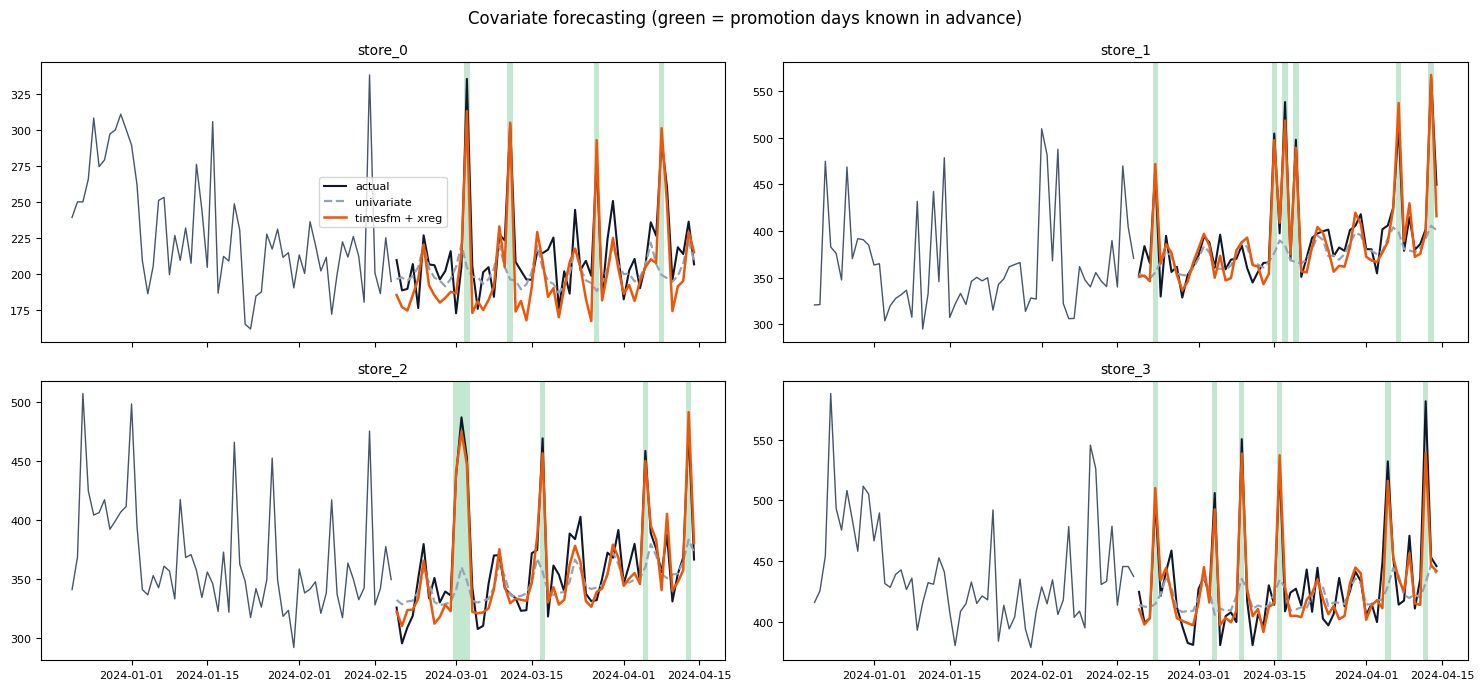


--- anomaly detection: 58 flags in 280 points (20.7% — expect ~20% by construction) ---
      date     actual         lo         hi     z      sev
2023-07-11 477.660004 337.140015 408.329987  4.05 CRITICAL
2023-08-22 469.880005 319.890015 393.549988  4.25 CRITICAL
2023-08-28 522.039978 313.660004 397.709991  5.44 CRITICAL
2023-09-18 657.119995 298.420013 375.290009 10.90 CRITICAL
2023-10-30 437.709991 282.660004 359.809998  4.15 CRITICAL
2023-10-31 446.480011 287.019989 363.320007  4.44 CRITICAL
2023-12-09 124.379997 296.299988 461.720001 -3.58 CRITICAL
2023-12-27 468.609985 288.869995 371.489990  4.57 CRITICAL
2024-02-01 509.679993 304.609985 402.869995  4.53 CRITICAL
2024-02-14 584.559998 309.850006 424.920013  5.27 CRITICAL
2024-02-16 704.609985 317.179993 449.059998  6.62 CRITICAL
2024-02-17 606.429993 325.829987 462.250000  4.37 CRITICAL
2024-03-26 167.850006 335.559998 464.079987 -4.14 CRITICAL
injected anomalies at: ['2023-09-18', '2023-12-09', '2024-02-14', '2024-03-26']


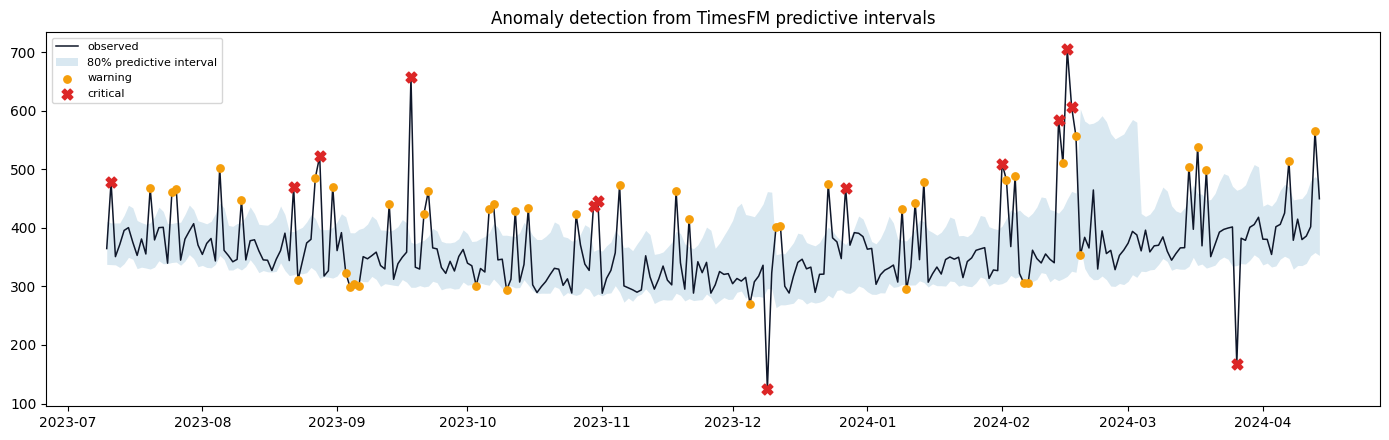


--- long horizon (256 days) ---
                  MAE    RMSE  MAPE%  sMAPE%   MASE  pinball  cov80%
direct         26.472  42.180  6.237   6.659  0.858   10.888  85.156
recursive x64  26.399  41.878  6.243   6.653  0.856      NaN     NaN


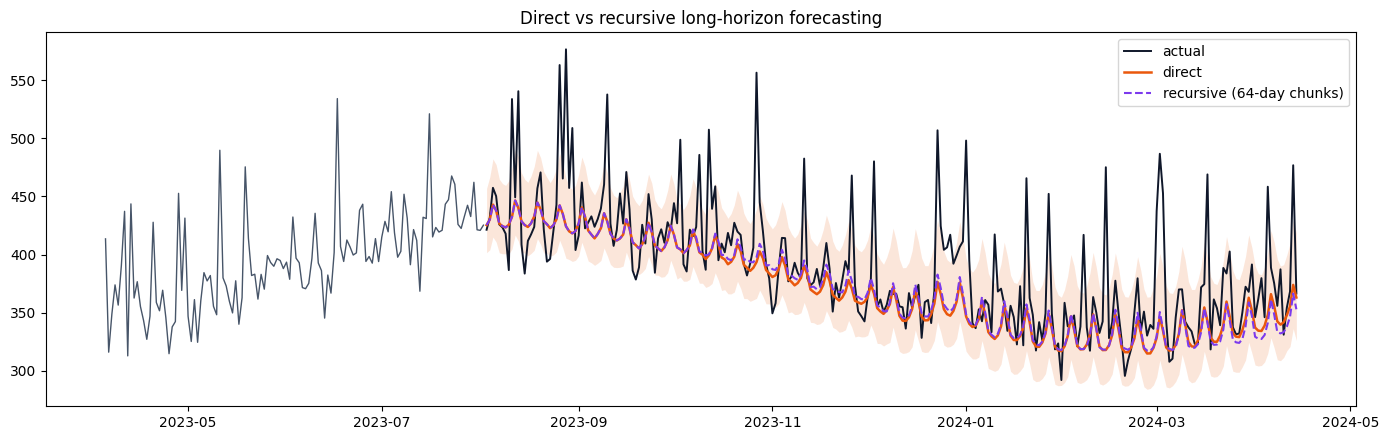


--- throughput (48 series, 1024 context) ---
 per_core_batch_size   sec  series/sec
                   1 57.55         0.8
                   4 30.76         1.6
                  16 24.25         2.0
                  32 31.61         1.5
                  48 24.27         2.0
Tip: also try force_flip_invariance=False for a ~2x speedup when your series are strictly positive — it removes the second forward pass.

--- robustness checks ---
(a) NaN input  -> finite output: True, MASE 0.605 (clean: 0.608)
(b) context=   8 -> 14d MASE 0.645
(b) context=  32 -> 14d MASE 0.602
(b) context= 128 -> 14d MASE 0.628
(c) decaying series: infer_is_positive=True  min=+0.0 (floored at 0) | False min=-54.0
(d) list length before=3 after=16  <-- pass list(inputs)!
(e) deterministic: True

Wrote timesfm_forecasts.csv and timesfm_backtest.json
      date   store   forecast        q10        q25        q50        q75        q90       mean
2024-04-15 store_0 209.899994 184.500000 199.000000 209.899994 222

In [1]:
many = [
    wide[STORES[i % len(STORES)]]
    .values[:-HORIZON]
    .astype(np.float32)
    .copy()
    for i in range(48)
]

print("\n--- throughput (48 series, 1024 context) ---")

bench = []

for bs in (
    [8, 32]
    if FAST_MODE
    else [1, 4, 16, 32, 48]
):
    recompile(per_core_batch_size=bs)

    model.forecast(
        horizon=32,
        inputs=[many[0].copy()]
    )

    t0 = time.time()

    model.forecast(
        horizon=HORIZON,
        inputs=list(many)
    )

    dt = time.time() - t0

    bench.append({
        "per_core_batch_size": bs,
        "sec": round(dt, 2),
        "series/sec": round(len(many) / dt, 1)
    })

bench = pd.DataFrame(bench)
print(bench.to_string(index=False))

print(
    "Tip: also try force_flip_invariance=False "
    "for a ~2x speedup when your series are "
    "strictly positive — it removes the second "
    "forward pass."
)

recompile()

print("\n--- robustness checks ---")

dirty = (
    wide[STORES[0]]
    .values[:-HORIZON]
    .astype(np.float32)
    .copy()
)

dirty[:20] = np.nan
dirty[400:415] = np.nan

p_nan, _ = model.forecast(
    horizon=HORIZON,
    inputs=[dirty.copy()]
)

print(
    f"(a) NaN input  -> finite output: "
    f"{np.isfinite(p_nan).all()}, "
    f"MASE "
    f"{evaluate(actual, p_nan[0], train)['MASE']:.3f} "
    f"(clean: "
    f"{evaluate(actual, point[0], train)['MASE']:.3f})"
)


def trim_trailing_nans(a):
    a = np.asarray(a, dtype=np.float32)
    return (
        a[:len(a) - np.argmax(~np.isnan(a[::-1]))]
        if np.isnan(a[-1])
        else a
    )


for L in [8, 32, 128]:
    ps, _ = model.forecast(
        horizon=14,
        inputs=[train[-L:].copy()]
    )

    print(
        f"(b) context={L:>4} -> 14d MASE "
        f"{evaluate("
        f"series[-HORIZON:-HORIZON+14], "
        f"ps[0], "
        f"train"
        f")['MASE']:.3f}"
    )

decay = np.clip(
    np.linspace(400, 8, 400) +
    np.random.normal(0, 6, 400),
    0,
    None
).astype(np.float32)

recompile(infer_is_positive=True)

p_clip, _ = model.forecast(
    horizon=64,
    inputs=[decay.copy()]
)

recompile(infer_is_positive=False)

p_free, _ = model.forecast(
    horizon=64,
    inputs=[decay.copy()]
)

print(
    f"(c) decaying series: "
    f"infer_is_positive=True "
    f"min={p_clip.min():+.1f} "
    f"(floored at 0) | "
    f"False min={p_free.min():+.1f}"
)

recompile()

probe = [
    train.copy(),
    train.copy(),
    train.copy()
]

before = len(probe)

model.forecast(
    horizon=16,
    inputs=probe
)

print(
    f"(d) list length before={before} "
    f"after={len(probe)} "
    f"<-- pass list(inputs)!"
)

r1, _ = model.forecast(
    horizon=32,
    inputs=[train.copy()]
)

r2, _ = model.forecast(
    horizon=32,
    inputs=[train.copy()]
)

print(
    f"(e) deterministic: "
    f"{np.allclose(r1, r2)}"
)

fc_dates = pd.date_range(
    dates[-1] + pd.Timedelta(days=1),
    periods=HORIZON,
    freq="D"
)

final_in = [
    wide[s]
    .values
    .astype(np.float32)
    .copy()
    for s in STORES
]

fp, fq = model.forecast(
    horizon=HORIZON,
    inputs=list(final_in)
)

out = []

for i, s in enumerate(STORES):
    out.append(pd.DataFrame({
        "date": fc_dates,
        "store": s,
        "forecast": fp[i],
        "q10": fq[i, :, IDX_Q10],
        "q25": fq[i, :, 3],
        "q50": fq[i, :, IDX_Q50],
        "q75": fq[i, :, 7],
        "q90": fq[i, :, IDX_Q90],
        "mean": fq[i, :, IDX_MEAN],
    }))

out = pd.concat(out, ignore_index=True)

out.to_csv(
    "timesfm_forecasts.csv",
    index=False
)

with open("timesfm_backtest.json", "w") as f:
    json.dump({
        "backtest": summary.round(4).to_dict(),
        "context_ablation": abl.round(4).to_dict(
            orient="records"
        ),
        "throughput": bench.to_dict(
            orient="records"
        )
    }, f, indent=2)

print(
    "\nWrote timesfm_forecasts.csv "
    "and timesfm_backtest.json"
)

print(
    out.head(4)
    .round(1)
    .to_string(index=False)
)

print("""
============================ USE IT ON YOUR OWN CSV ==========================
df   = pd.read_csv("mydata.csv", parse_dates=["date"]).sort_values("date")
vals = df["value"].astype("float32").to_numpy()          # 1-D, evenly spaced!

model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
            "google/timesfm-2.5-200m-pytorch")
model.compile(timesfm.ForecastConfig(
    max_context=1024, max_horizon=128, normalize_inputs=True,
    per_core_batch_size=32, use_continuous_quantile_head=True,
    fix_quantile_crossing=True, infer_is_positive=True))

point, quant = model.forecast(horizon=30, inputs=[vals])
lower, median, upper = quant[0,:,1], point[0], quant[0,:,9]

CHECKLIST
  [ ] regular spacing, one row per period, gaps as NaN (not dropped rows)
  [ ] trim trailing NaNs yourself
  [ ] max_context multiple of 32; max_horizon multiple of 128
  [ ] max_context + max_horizon <= 16384; horizon <= 1024 w/ quantile head
  [ ] quantile index 0 = MEAN, 1..9 = q10..q90, 5 = median
  [ ] infer_is_positive=False for anything that can go negative
  [ ] return_backcast=True only for forecast_with_covariates()
  [ ] dynamic covariates must cover context + horizon
  [ ] pass list(inputs) — forecast() mutates the list it is given
  [ ] backtest with rolling origins and compare against seasonal naive
=============================================================================""")